In [115]:
import csv
import numpy as np
import matplotlib.pyplot as plt

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

In [116]:
# xml_file = "../data/antoine/plateforme/test3.xml"
# csv_gait_file = "../data/antoine/plateforme/test3/gait-line.csv"


In [117]:
xml_file = "../data/kelly/plat.xml"
csv_gait_file = "../data/kelly/gait-line.csv"

In [118]:
import xml.etree.ElementTree as ET

def get_begin_time(xml_filepath_filenam):
    tree = ET.parse(xml_filepath_filenam)
    root = tree.getroot()

    # définir le namespace
    ns = {"z": "http://www.zebris.de/measurements"}

    # trouver la valeur de begin
    begin = root.find(".//z:clip/z:begin", ns)

    if begin is not None:
        return float(begin.text)
    return 0

print(get_begin_time(xml_file))

-10.1


In [119]:
def get_gait_samples(csv_file):
    times = []
    xs = []
    ys = []

    with open(csv_file, newline='', encoding="utf-8") as csvfile:
        reader = list(csv.reader(csvfile))

        # ---- Lire le nombre de lignes de données (count) ----
        count = int(reader[1][5])  # 6e élément de la 2e ligne

        # ---- Les données commencent à la ligne 5 (index 4) ----
        start_line = 4
        end_line = start_line + count

        for row in reader[start_line:end_line]:
            time = float(row[0])
            x = float(row[1])
            y = float(row[2])
            
            times.append(time)
            xs.append(x)
            ys.append(y)
        
        return np.array(times), np.array(xs), np.array(ys)


In [120]:
begin_time = get_begin_time(xml_file)
times, x_pos, y_pos = get_gait_samples(csv_gait_file)


In [121]:
times = times + begin_time

positive_time = np.where(times > 0)
times = times[positive_time]
x_pos = x_pos[positive_time]
y_pos = y_pos[positive_time]

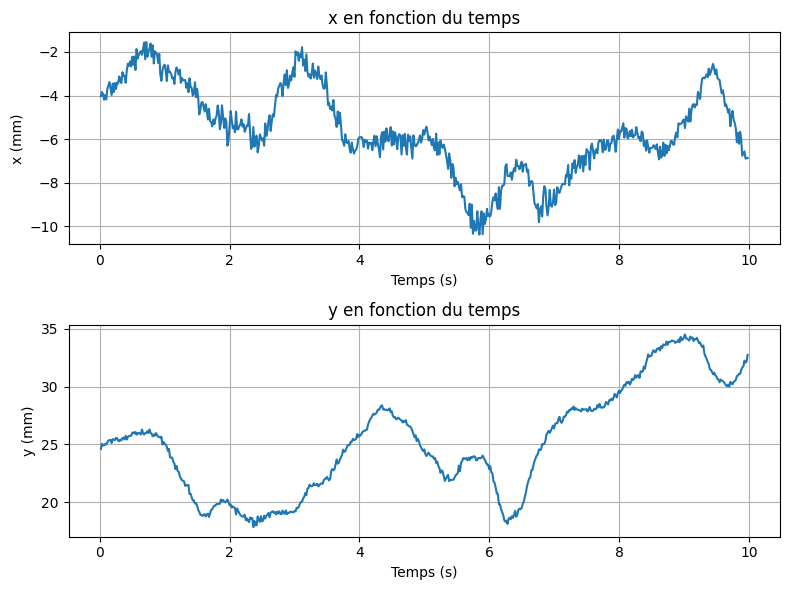

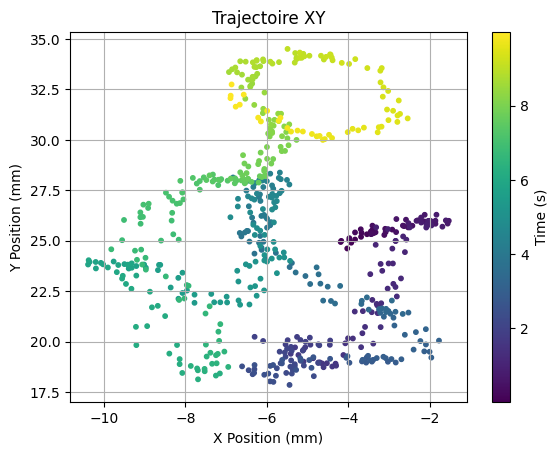

In [122]:
# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x (mm)")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y (mm)")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


In [123]:
x_mean = np.mean(x_pos)
y_mean = np.mean(y_pos)
print(f"Mean X: {x_mean:.4f} m, Mean Y: {y_mean:.4f} m")

Mean X: -5.5821 m, Mean Y: 25.2160 m


In [124]:
x_pos -= x_mean
y_pos -= y_mean

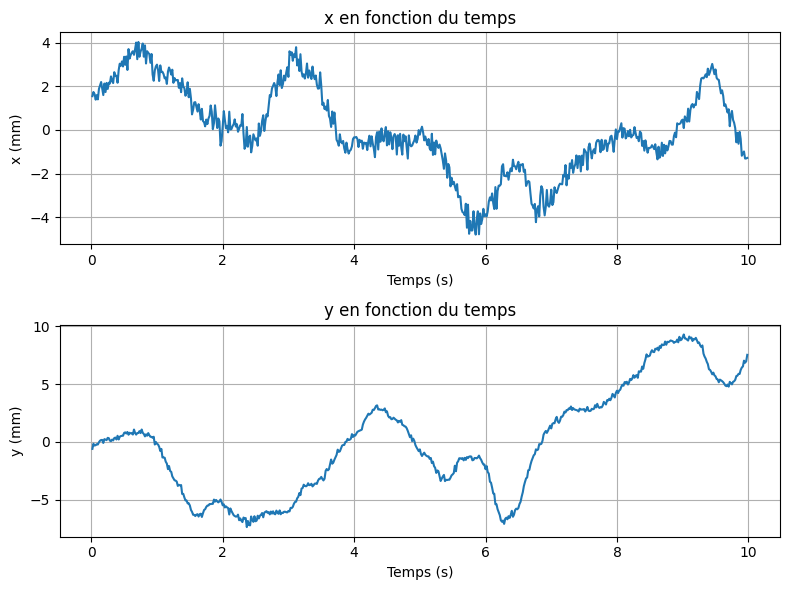

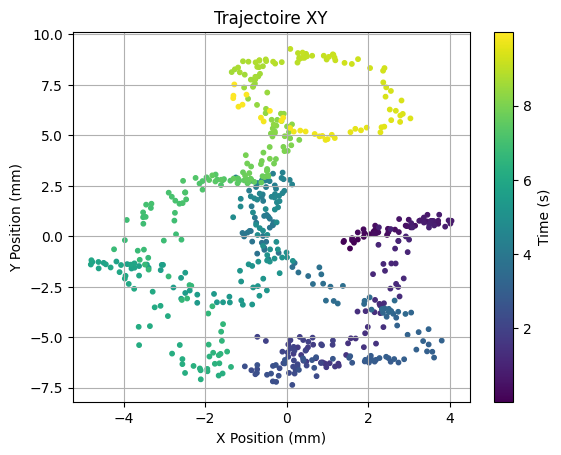

In [125]:
# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x (mm)")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y (mm)")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


In [126]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

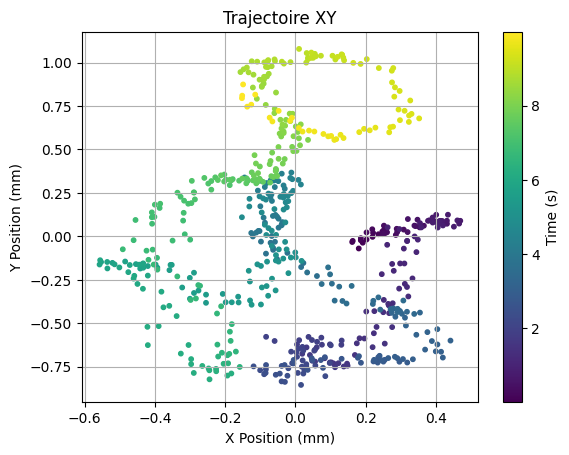

In [127]:
plt.figure()
sc = plt.scatter(x_norm, y_norm, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [128]:
data = np.array([x_pos/10, y_pos/10]).T

stato = Stabilogram()
stato.from_array(array=data, original_frequency=60)

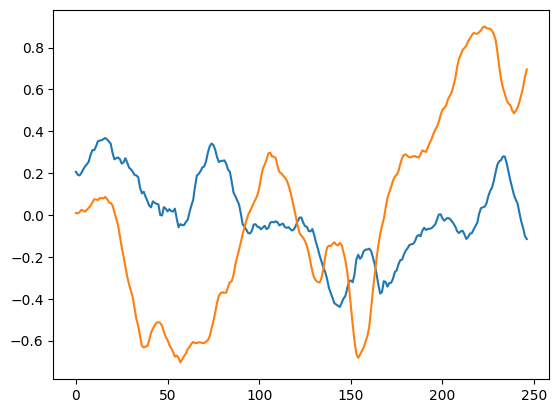

In [129]:
plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [130]:
sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 247, using nperseg = 247
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [131]:
features

{'mean_value_ML': np.float64(-1.8951636772608057e-17),
 'mean_value_AP': np.float64(-2.481784023327353e-16),
 'mean_distance_ML': np.float64(0.15716857511952703),
 'mean_distance_AP': np.float64(0.3809021816113472),
 'mean_distance_Radius': np.float64(0.45076143622763004),
 'maximal_distance_ML': np.float64(0.43891554941638916),
 'maximal_distance_AP': np.float64(0.9008553001644901),
 'maximal_distance_Radius': np.float64(0.9017540200994293),
 'rms_ML': np.float64(0.19638004102566559),
 'rms_AP': np.float64(0.4579003344930156),
 'rms_Radius': np.float64(0.49823472063080637),
 'range_ML': np.float64(0.8068753350073852),
 'range_AP': np.float64(1.605261684170829),
 'range_ML_AND_AP': np.float64(1.607438945729263),
 'range_ratio_ML_AND_AP': np.float64(0.5026441127722818),
 'planar_deviation_ML_AND_AP': np.float64(0.49823472063080637),
 'coefficient_sway_direction_ML_AND_AP': np.float64(-0.026833390950226747),
 'confidence_ellipse_area_ML_AND_AP': np.float64(1.7267905506597894),
 'principa